# 1. Import Required Libraries

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter


# 2. Load and Create the Graph

In [2]:
# Load the edge list from the file
file_path = "facebook_combined.txt"

# Read the graph
G = nx.read_edgelist(file_path, nodetype=int)

# Summary of the graph
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())


Number of nodes: 4039
Number of edges: 88234


# 3. Basic Analysis

Node Degrees (first 10): [(0, 347), (1, 17), (2, 10), (3, 17), (4, 10), (5, 13), (6, 6), (7, 20), (8, 8), (9, 57)]


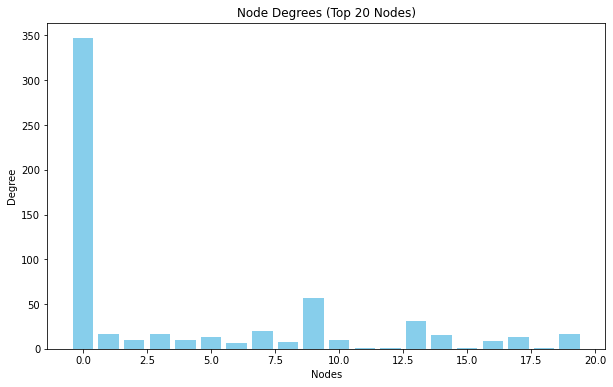

Average Degree: 43.69


In [3]:

# Node degrees
degrees = dict(G.degree())
print("Node Degrees (first 10):", list(degrees.items())[:10])

# Visualization
plt.figure(figsize=(10, 6))
plt.bar(list(degrees.keys())[:20], list(degrees.values())[:20], color='skyblue')
plt.title("Node Degrees (Top 20 Nodes)")
plt.xlabel("Nodes")
plt.ylabel("Degree")
plt.show()

average_degree = sum(degrees.values()) / G.number_of_nodes()
print(f"Average Degree: {average_degree:.2f}")

# 4. Visualization

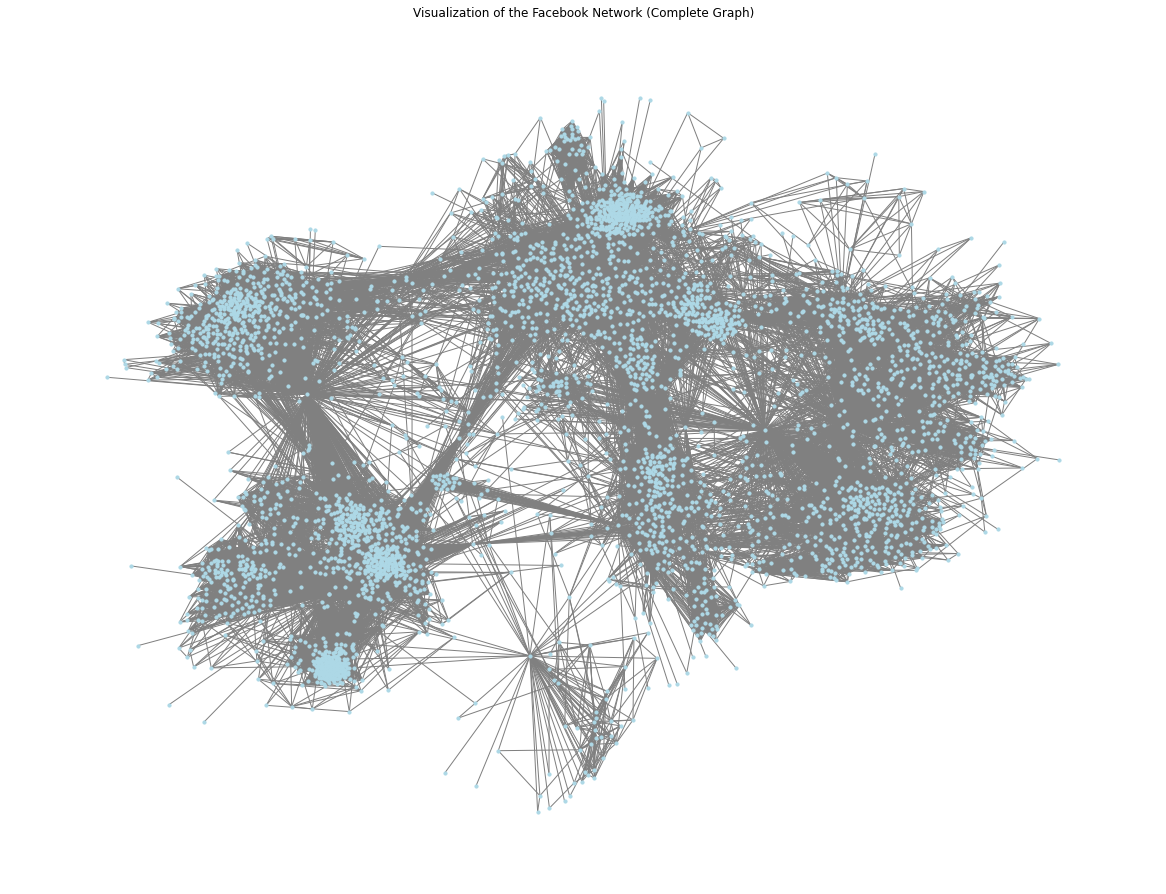

In [4]:
plt.figure(figsize=(16, 12))

# Use a layout for better visualization
pos = nx.spring_layout(G, k=0.1)  # Spring layout positions nodes based on edge forces

nx.draw(
    G, 
    pos, 
    node_color='lightblue', 
    edge_color='gray', 
    node_size=10,  # Smaller node size for clarity
    with_labels=False  # Avoid cluttering with labels
)
plt.title("Visualization of the Facebook Network (Complete Graph)")
plt.show()


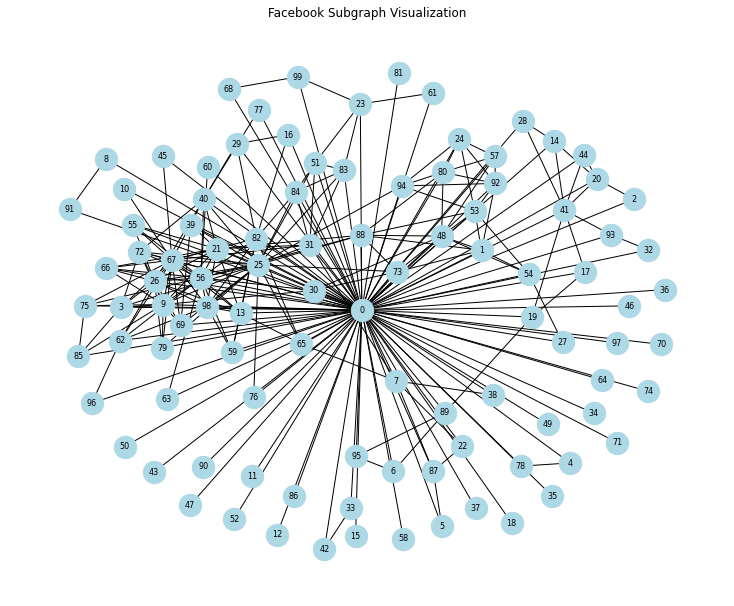

In [5]:
import matplotlib.pyplot as plt

# Visualize a subgraph of 100 nodes
subgraph = G.subgraph(list(G.nodes)[:100])

plt.figure(figsize=(10, 8))
nx.draw(subgraph, with_labels=True, node_color='lightblue', node_size=500, font_size=8)
plt.title("Facebook Subgraph Visualization")
plt.show()


# special graphs

Complete Graph - Nodes: 30 Edges: 435


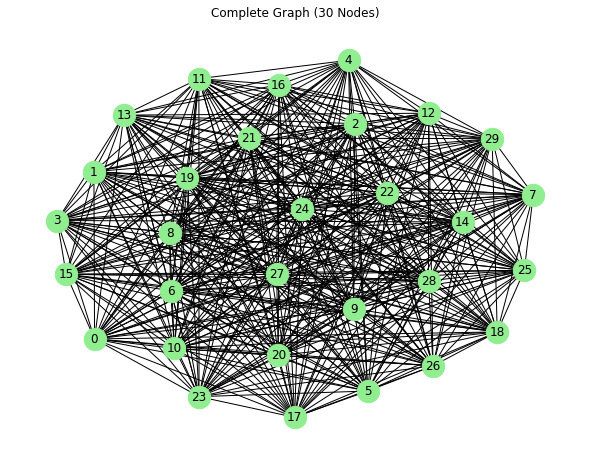

Cycle Graph - Nodes: 30 Edges: 30


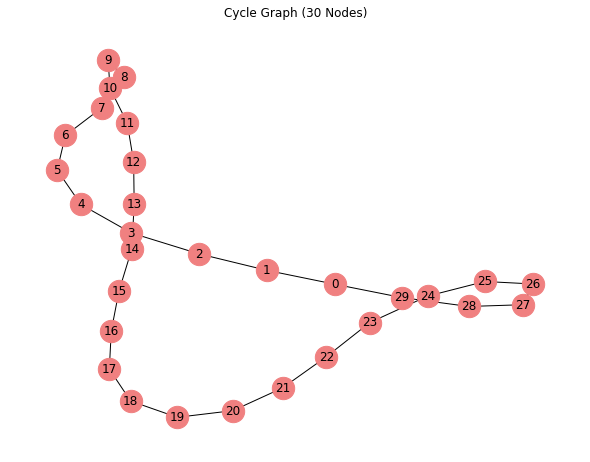

In [6]:
# Generate special graphs
complete_graph = nx.complete_graph(30)
print("Complete Graph - Nodes:", complete_graph.number_of_nodes(), "Edges:", complete_graph.number_of_edges())
# Visualize complete graph
plt.figure(figsize=(8, 6))
nx.draw(complete_graph, with_labels=True, node_color='lightgreen', node_size=500)
plt.title("Complete Graph (30 Nodes)")
plt.show()

cycle_graph = nx.cycle_graph(30)
print("Cycle Graph - Nodes:", cycle_graph.number_of_nodes(), "Edges:", cycle_graph.number_of_edges())
# Visualize cycle graph
plt.figure(figsize=(8, 6))
nx.draw(cycle_graph, with_labels=True, node_color='lightcoral', node_size=500)
plt.title("Cycle Graph (30 Nodes)")
plt.show()


# 5. Connectivity Analysis

In [7]:
# Check if the graph is connected
is_connected = nx.is_connected(G)
if is_connected:
    print("The graph is connected.")
else:
    print("The graph is not connected. Number of components:", nx.number_connected_components(G))
    largest_cc = max(nx.connected_components(G), key=len)
    print("Size of the largest connected component:", len(largest_cc))
    
    
# # Check connectivity
# is_connected = nx.is_connected(G)
# print("Is the graph connected?", is_connected)

# # Find largest connected component if not connected
# if not is_connected:
#     components = nx.connected_components(G)
#     largest_component = max(components, key=len)
#     print(f"Largest Connected Component Size: {len(largest_component)}")



The graph is connected.


# Step 6: Matrix Representation

In [8]:
import numpy as np

# Adjacency Matrix
adj_matrix = nx.adjacency_matrix(G).todense()
print("Adjacency Matrix (first 30 rows):")
print(np.array(adj_matrix)[:30, :30])


Adjacency Matrix (first 30 rows):
[[0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0]
 [1 0 0 0 0 0 0 0 0 0

# Representing graph (Edge List or Adjacent List)

In [9]:
# # Edge List
# print("Edge List (first 10 edges):", list(G.edges)[:10])

# Adjacency List
adj_list = {node: list(neighbors) for node, neighbors in G.adjacency()}
print("Adjacency List (first 10 nodes):", dict(list(adj_list.items())[:10]))


Adjacency List (first 10 nodes): {0: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 

## Adjacency List  is better because it allows us to quickly retrieve all neighbors of a given node. It is easier to work with if network is: 
### • Large
### • Sparse

#  Quantifying social structure

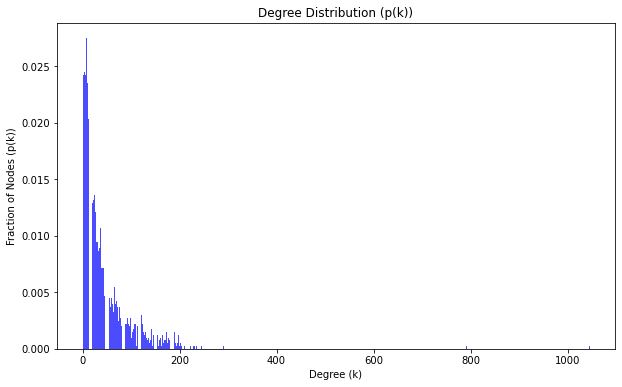

{'Degree Distribution (p(k))': [0.0,
  0.018568952711067097,
  0.024263431542461005,
  0.0230255013617232,
  0.024511017578608567,
  0.0230255013617232,
  0.024263431542461005,
  0.024263431542461005,
  0.027482050012379303,
  0.02475860361475613],
 'Average Path Length (h)': 3.6925068496963913,
 'Clustering Coefficient (C)': 0.6055467186200876,
 'Number of Connected Components (s)': 1}

In [10]:
# 1. Degree Distribution (p(k))
degree_sequence = [d for n, d in G.degree()]
max_degree = max(degree_sequence)
degree_counts = [degree_sequence.count(k) for k in range(max_degree + 1)]
p_k = [count / len(G.nodes) for count in degree_counts]

# Plot Degree Distribution
plt.figure(figsize=(10, 6))
plt.bar(range(len(p_k)), p_k, color='blue', alpha=0.7)
plt.title("Degree Distribution (p(k))")
plt.xlabel("Degree (k)")
plt.ylabel("Fraction of Nodes (p(k))")
plt.show()

# 2. Path Length (h)
if nx.is_connected(G):
    h = nx.average_shortest_path_length(G)
else:
    # For disconnected graphs, calculate for the largest connected component
    largest_cc = max(nx.connected_components(G), key=len)
    G_largest_cc = G.subgraph(largest_cc)
    h = nx.average_shortest_path_length(G_largest_cc)

# 3. Clustering Coefficient (C)
C = nx.average_clustering(G)

# 4. Connected Components (s)
s = nx.number_connected_components(G)

# Summary of Results
quantifying_social_structure = {
    "Degree Distribution (p(k))": p_k[:10],  # Showing the first 10 probabilities
    "Average Path Length (h)": h,
    "Clustering Coefficient (C)": C,
    "Number of Connected Components (s)": s
}

quantifying_social_structure

# Centrality Measures 

# Top Centrality Scores

In [11]:
# Degree Centrality
degree_centrality = nx.degree_centrality(G)
print("Top 5 nodes by Degree Centrality:", sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10])

# Betweenness Centrality
betweenness_centrality = nx.betweenness_centrality(G)
print("Top 5 nodes by Betweenness Centrality:", sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10])

# Closeness Centrality
closeness_centrality = nx.closeness_centrality(G)
print("Top 5 nodes by Closeness Centrality:", sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:10])


Top 5 nodes by Degree Centrality: [(107, 0.258791480931154), (1684, 0.1961367013372957), (1912, 0.18697374938088163), (3437, 0.13546310054482416), (0, 0.08593363051015354), (2543, 0.07280832095096582), (2347, 0.07206537890044576), (1888, 0.0629024269440317), (1800, 0.06067360079247152), (1663, 0.058197127290737984)]
Top 5 nodes by Betweenness Centrality: [(107, 0.4805180785560152), (1684, 0.3377974497301992), (3437, 0.23611535735892905), (1912, 0.2292953395868782), (1085, 0.14901509211665306), (0, 0.14630592147442917), (698, 0.11533045020560802), (567, 0.09631033121856215), (58, 0.08436020590796486), (428, 0.06430906239323866)]
Top 5 nodes by Closeness Centrality: [(107, 0.45969945355191255), (58, 0.3974018305284913), (428, 0.3948371956585509), (563, 0.3939127889961955), (1684, 0.39360561458231796), (171, 0.37049270575282134), (348, 0.36991572004397216), (483, 0.3698479575013739), (414, 0.3695433330282786), (376, 0.36655773420479304)]


# Visualization of Top Centrality Measures

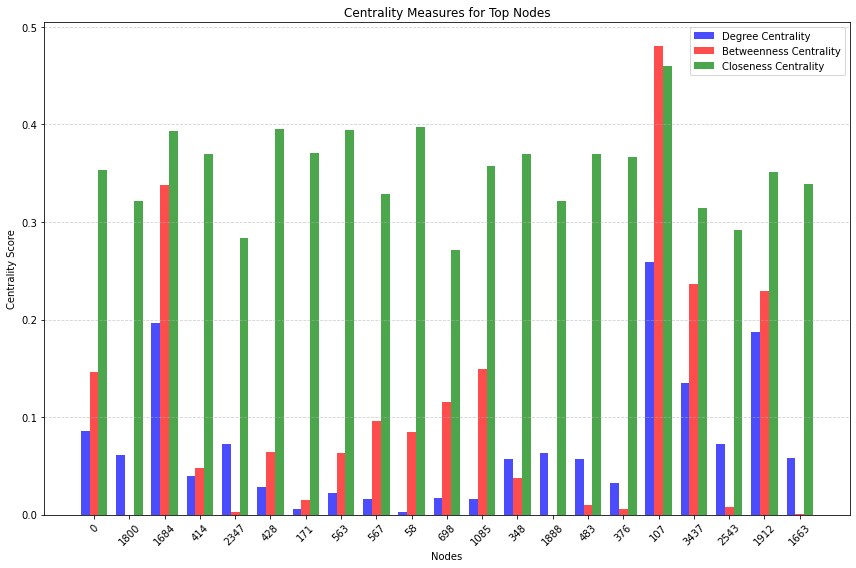

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for top 10 nodes
top_nodes = list(set(
    [node for node, _ in sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]] +
    [node for node, _ in sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]] +
    [node for node, _ in sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]]
))

degree_scores = [degree_centrality.get(node, 0) for node in top_nodes]
betweenness_scores = [betweenness_centrality.get(node, 0) for node in top_nodes]
closeness_scores = [closeness_centrality.get(node, 0) for node in top_nodes]

# Create the grouped bar chart
x = np.arange(len(top_nodes))  # Node indices
width = 0.25  # Bar width

plt.figure(figsize=(12, 8))
plt.bar(x - width, degree_scores, width, label='Degree Centrality', color='blue', alpha=0.7)
plt.bar(x, betweenness_scores, width, label='Betweenness Centrality', color='red', alpha=0.7)
plt.bar(x + width, closeness_scores, width, label='Closeness Centrality', color='green', alpha=0.7)

# Add labels and legend
plt.title("Centrality Measures for Top Nodes")
plt.xlabel("Nodes")
plt.ylabel("Centrality Score")
plt.xticks(x, top_nodes, rotation=45)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Show the plot
plt.tight_layout()
plt.show()


 # Lowest Centrality Scores

In [13]:
# Degree Centrality
low_degree = sorted(degree_centrality.items(), key=lambda x: x[1])[:10]
print("Bottom 10 nodes by Degree Centrality:", low_degree)

# Betweenness Centrality
low_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1])[:10]
print("Bottom 10 nodes by Betweenness Centrality:", low_betweenness)

# Closeness Centrality
low_closeness = sorted(closeness_centrality.items(), key=lambda x: x[1])[:10]
print("Bottom 10 nodes by Closeness Centrality:", low_closeness)


Bottom 10 nodes by Degree Centrality: [(11, 0.00024764735017335313), (12, 0.00024764735017335313), (15, 0.00024764735017335313), (18, 0.00024764735017335313), (37, 0.00024764735017335313), (43, 0.00024764735017335313), (74, 0.00024764735017335313), (114, 0.00024764735017335313), (209, 0.00024764735017335313), (210, 0.00024764735017335313)]
Bottom 10 nodes by Betweenness Centrality: [(11, 0.0), (12, 0.0), (15, 0.0), (18, 0.0), (32, 0.0), (33, 0.0), (35, 0.0), (37, 0.0), (42, 0.0), (43, 0.0)]
Bottom 10 nodes by Closeness Centrality: [(692, 0.1782545358230698), (801, 0.1782545358230698), (699, 0.17826240508564364), (744, 0.17826240508564364), (749, 0.17826240508564364), (750, 0.17826240508564364), (775, 0.17826240508564364), (841, 0.17826240508564364), (743, 0.17827027504304446), (785, 0.17827027504304446)]


#  Visualization of Lowest Centrality Measures

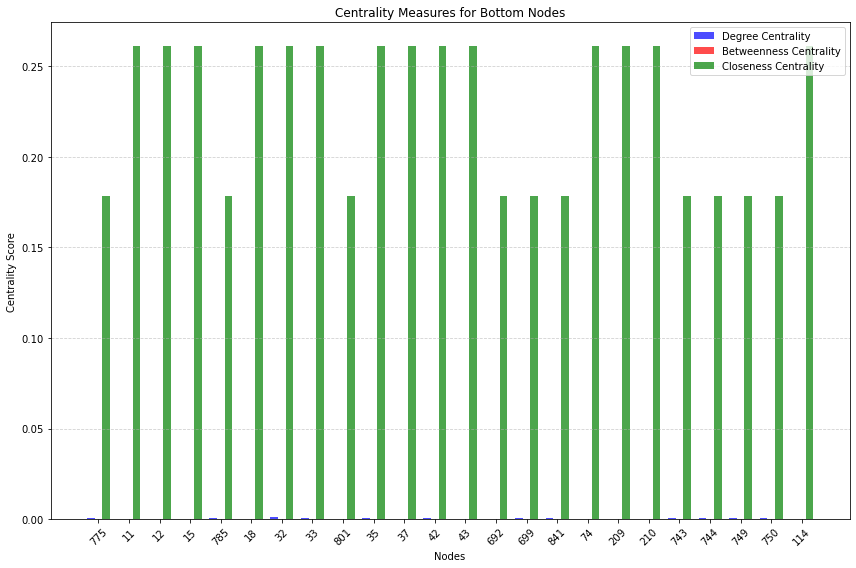

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for bottom 10 nodes
low_nodes = list(set(
    [node for node, _ in sorted(degree_centrality.items(), key=lambda x: x[1])[:10]] +
    [node for node, _ in sorted(betweenness_centrality.items(), key=lambda x: x[1])[:10]] +
    [node for node, _ in sorted(closeness_centrality.items(), key=lambda x: x[1])[:10]]
))

degree_scores = [degree_centrality.get(node, 0) for node in low_nodes]
betweenness_scores = [betweenness_centrality.get(node, 0) for node in low_nodes]
closeness_scores = [closeness_centrality.get(node, 0) for node in low_nodes]

# Create the grouped bar chart
x = np.arange(len(low_nodes))  # Node indices
width = 0.25  # Bar width

plt.figure(figsize=(12, 8))
plt.bar(x - width, degree_scores, width, label='Degree Centrality', color='blue', alpha=0.7)
plt.bar(x, betweenness_scores, width, label='Betweenness Centrality', color='red', alpha=0.7)
plt.bar(x + width, closeness_scores, width, label='Closeness Centrality', color='green', alpha=0.7)

# Add labels and legend
plt.title("Centrality Measures for Bottom Nodes")
plt.xlabel("Nodes")
plt.ylabel("Centrality Score")
plt.xticks(x, low_nodes, rotation=45)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Show the plot
plt.tight_layout()
plt.show()


# Community Detection

In [15]:
from networkx.algorithms.community import greedy_modularity_communities

# Detect communities
communities = list(greedy_modularity_communities(G))
print(f"Detected {len(communities)} communities")
for i, community in enumerate(communities[:5], 1):  # Display first 5 communities
    print(f"Community {i}: {sorted(community)}")


Detected 13 communities
Community 1: [897, 899, 906, 908, 916, 920, 921, 922, 923, 925, 926, 927, 928, 929, 932, 934, 946, 947, 950, 951, 952, 953, 959, 960, 961, 966, 967, 970, 972, 973, 978, 980, 982, 983, 990, 991, 993, 995, 996, 997, 998, 999, 1003, 1004, 1006, 1008, 1017, 1023, 1024, 1026, 1028, 1029, 1031, 1033, 1034, 1038, 1039, 1040, 1047, 1048, 1049, 1050, 1054, 1055, 1056, 1058, 1059, 1061, 1063, 1068, 1069, 1073, 1074, 1075, 1076, 1077, 1078, 1079, 1083, 1084, 1086, 1087, 1088, 1091, 1092, 1098, 1101, 1107, 1110, 1112, 1116, 1117, 1123, 1124, 1125, 1126, 1128, 1130, 1132, 1133, 1135, 1136, 1140, 1144, 1146, 1149, 1150, 1153, 1156, 1157, 1160, 1161, 1163, 1164, 1165, 1172, 1173, 1174, 1175, 1178, 1180, 1181, 1182, 1184, 1185, 1187, 1191, 1195, 1196, 1198, 1199, 1201, 1205, 1207, 1209, 1211, 1214, 1219, 1220, 1222, 1230, 1238, 1239, 1242, 1243, 1250, 1251, 1255, 1256, 1265, 1266, 1267, 1269, 1271, 1272, 1274, 1278, 1280, 1283, 1285, 1287, 1288, 1289, 1290, 1291, 1293, 1301, 13

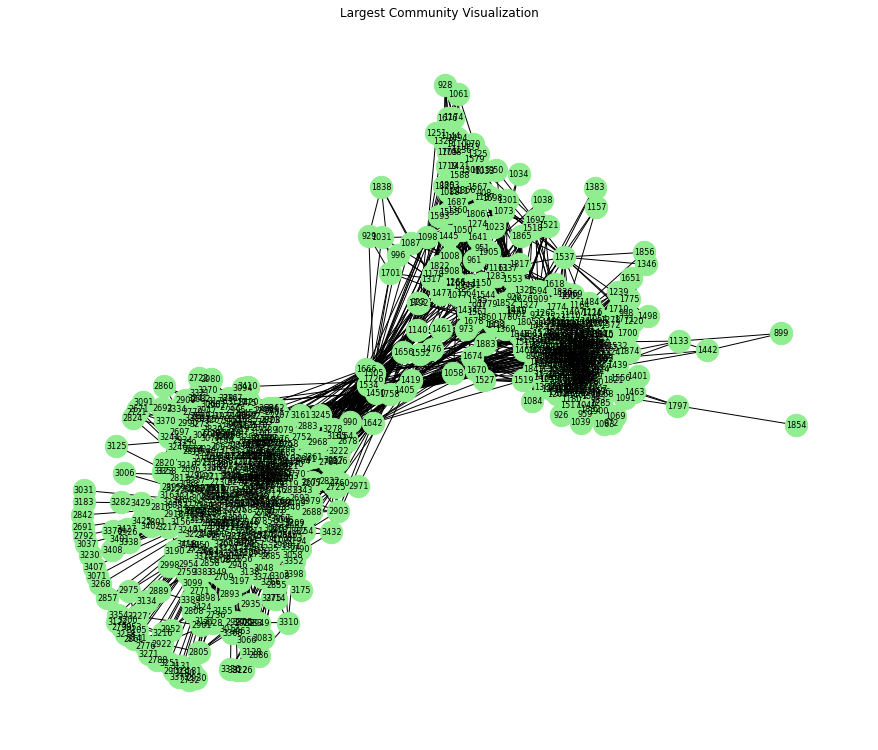

In [20]:
# Visualize nodes in the largest community
largest_community = communities[0]
subgraph = G.subgraph(largest_community)

plt.figure(figsize=(12, 10))
nx.draw(subgraph, with_labels=True, node_color='lightgreen', node_size=500, font_size=8)
plt.title("Largest Community Visualization")
plt.show()
